# Dia 4 — Machine Learning Introdutório
Dataset: Diamantes (limpo) | Objetivo: prever o preço de um diamante a partir de suas características

## Imports e carregamento dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Carrega o dataset já limpo
df = pd.read_csv('../data/diamonds_clean.csv')

print("Shape:", df.shape)
df.head()

Shape: (53917, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Preparação das Features
Machine Learning só trabalha com números. As colunas `cut`, `color` e `clarity` são texto — precisamos convertê-las para números antes de treinar o modelo.
Esse processo se chama **encoding**.

In [2]:
# Converte colunas categóricas em números
df_modelo = pd.get_dummies(df, columns=['cut', 'color', 'clarity'])

# Separa features (X) e target (y)
X = df_modelo.drop(columns=['price'])
y = df_modelo['price']

print("Features (X):", X.shape)
print("Target (y):", y.shape)
print("\nColunas do modelo:")
print(X.columns.tolist())

Features (X): (53917, 26)
Target (y): (53917,)

Colunas do modelo:
['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_Fair', 'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good', 'color_D', 'color_E', 'color_F', 'color_G', 'color_H', 'color_I', 'color_J', 'clarity_I1', 'clarity_IF', 'clarity_SI1', 'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2']


## Divisão Treino e Teste
Separamos os dados em dois grupos:
- **Treino (80%):** o modelo aprende os padrões
- **Teste (20%):** avaliamos se o modelo aprendeu de verdade

Nunca avaliamos o modelo com os mesmos dados que ele usou para aprender — seria como dar a prova com o gabarito.

In [3]:
# Divide os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Treino:", X_train.shape)
print("Teste: ", X_test.shape)

Treino: (43133, 26)
Teste:  (10784, 26)


## Treinamento do Modelo
Usamos Regressão Linear — o modelo mais simples de Machine Learning.
Ele encontra a melhor reta que relaciona as features com o preço.
Como um ourives experiente que, depois de ver milhares de pedras, consegue estimar o valor só de olhar para as características.

In [4]:
# Cria e treina o modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")
print(f"Número de features usadas: {modelo.n_features_in_}")

Modelo treinado com sucesso!
Número de features usadas: 26


## Avaliação do Modelo
Agora testamos o modelo com dados que ele nunca viu.
- **MAE** (Mean Absolute Error): erro médio em dólares — quanto o modelo erra na média
- **R²** (R-squared): o quanto o modelo explica a variação dos preços (0 = nada, 1 = perfeito)

In [5]:
# Faz previsões no conjunto de teste
y_pred = modelo.predict(X_test)

# Calcula as métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  $ {mae:.2f}")
print(f"R²:     {r2:.4f}")

MAE:  $ 716.53
R²:     0.9246


## Visualização — Previsto vs Real
Comparamos graficamente os preços reais com os preços previstos pelo modelo.
Em um modelo perfeito, todos os pontos estariam sobre a linha diagonal.

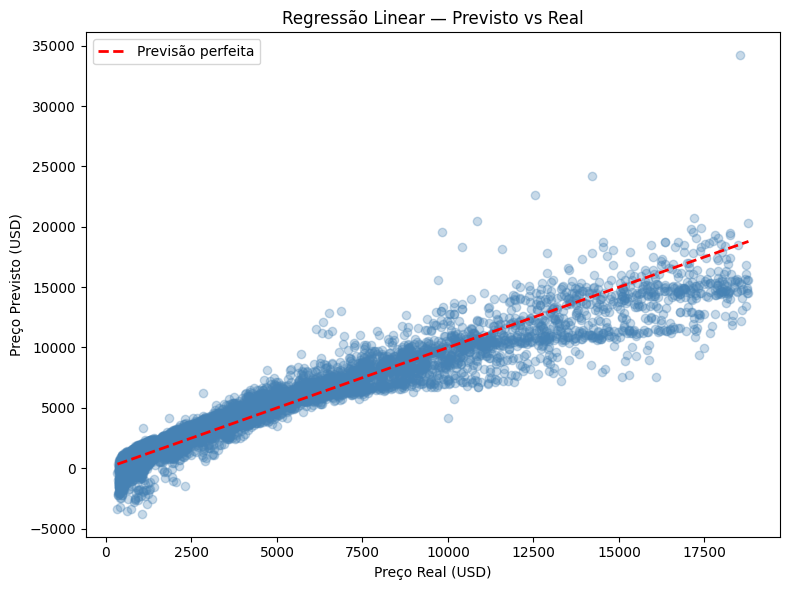

In [7]:
# Gráfico previsto vs real
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Previsão perfeita')

plt.xlabel("Preço Real (USD)")
plt.ylabel("Preço Previsto (USD)")
plt.title("Regressão Linear — Previsto vs Real")
plt.legend()
plt.tight_layout()
plt.show()

## Previsão Manual
Testamos o modelo com um diamante fictício — como um ourives avaliando uma peça específica.

In [8]:
# Cria um diamante fictício para testar
diamante = pd.DataFrame([{
    'carat': 1.0, 'depth': 61.5, 'table': 57.0,
    'x': 6.4, 'y': 6.4, 'z': 3.9,
    'cut_Fair': 0, 'cut_Good': 0, 'cut_Ideal': 1,
    'cut_Premium': 0, 'cut_Very Good': 0,
    'color_D': 1, 'color_E': 0, 'color_F': 0,
    'color_G': 0, 'color_H': 0, 'color_I': 0, 'color_J': 0,
    'clarity_I1': 0, 'clarity_IF': 1, 'clarity_SI1': 0,
    'clarity_SI2': 0, 'clarity_VS1': 0, 'clarity_VS2': 0,
    'clarity_VVS1': 0, 'clarity_VVS2': 0
}])

preco_previsto = modelo.predict(diamante)[0]
print(f"Diamante: 1 quilate, corte Ideal, cor D, clareza IF")
print(f"Preço previsto: $ {preco_previsto:.2f}")

Diamante: 1 quilate, corte Ideal, cor D, clareza IF
Preço previsto: $ 7630.70


## Resumo do Modelo
Consolidando os resultados e aprendizados do dia.

In [9]:
print("=== Resumo do Modelo — Regressão Linear ===")
print(f"Dataset:        {len(df):,} diamantes")
print(f"Features:       {X.shape[1]} variáveis")
print(f"Treino/Teste:   80% / 20%")
print(f"R²:             {r2:.4f} (explica {r2*100:.1f}% da variação de preço)")
print(f"MAE:            $ {mae:.2f} (erro médio por diamante)")
print(f"\nPrevisão exemplo:")
print(f"  1 quilate | Ideal | cor D | clareza IF → $ {preco_previsto:.2f}")

=== Resumo do Modelo — Regressão Linear ===
Dataset:        53,917 diamantes
Features:       26 variáveis
Treino/Teste:   80% / 20%
R²:             0.9246 (explica 92.5% da variação de preço)
MAE:            $ 716.53 (erro médio por diamante)

Previsão exemplo:
  1 quilate | Ideal | cor D | clareza IF → $ 7630.70
